# SIMULACIONES

Creo un video con una animación de la matriz de matriz.txt para ver las partículas.

In [18]:
### PARA VIDEO ##########################

# Cada cuántas filas/columnas quiero una línea gruesa
division_N = 10   # filas
division_M = 10   # columnas

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cv2

# =========================================================
# PARÁMETROS
# =========================================================
nombre_archivo = "MATRIZ.txt"
nombre_video = "evolucion_matriz.mp4"
fps = 10



# Grosor de líneas
grosor_linea_normal = 0.5
grosor_linea_gruesa = 2.5

# =========================================================
# FUNCIÓN PARA LEER LAS MATRICES DEL ARCHIVO
# =========================================================
def leer_matrices(nombre_archivo):
    with open(nombre_archivo, "r") as f:
        lineas = f.readlines()

    matrices = []
    bloque = []

    for linea in lineas:
        linea = linea.strip()

        if linea == "":
            if bloque:
                matriz = []
                for fila in bloque:
                    valores = [int(x) for x in fila.split()]
                    matriz.append(valores)
                matrices.append(np.array(matriz))
                bloque = []
        else:
            bloque.append(linea)

    # Por si el archivo no termina con línea vacía
    if bloque:
        matriz = []
        for fila in bloque:
            valores = [int(x) for x in fila.split()]
            matriz.append(valores)
        matrices.append(np.array(matriz))

    return matrices

# =========================================================
# LEER MATRICES
# =========================================================
matrices = leer_matrices(nombre_archivo)

if len(matrices) == 0:
    raise ValueError("No se ha encontrado ninguna matriz en el archivo.")

n_filas, n_columnas = matrices[0].shape

# =========================================================
# MAPA DE COLORES
# 0 -> blanco
# 1 -> azul
# 2 -> rojo
# =========================================================
cmap = ListedColormap(["white", "blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# =========================================================
# CREAR FIGURA
# =========================================================
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ancho = int(fig.get_figwidth() * fig.dpi)
alto = int(fig.get_figheight() * fig.dpi)

# =========================================================
# CREAR EL ESCRITOR DE VÍDEO
# =========================================================
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter(nombre_video, fourcc, fps, (ancho, alto))

if not video.isOpened():
    raise ValueError("No se pudo abrir el escritor de vídeo. Prueba a instalar opencv correctamente o usar otro codec.")

# =========================================================
# GENERAR LOS FRAMES
# =========================================================
for contador, matriz in enumerate(matrices):
    ax.clear()

    ax.imshow(matriz, cmap=cmap, norm=norm)

    # =====================================================
    # CUADRÍCULA FINA NORMAL
    # =====================================================
    ax.set_xticks(np.arange(-0.5, n_columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_filas, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=grosor_linea_normal)

    # =====================================================
    # LÍNEAS GRUESAS CADA division_M COLUMNAS
    # =====================================================
    for columna in range(0, n_columnas + 1, division_M):
        x = columna - 0.5
        ax.axvline(x=x, color="black", linewidth=grosor_linea_gruesa)

    # =====================================================
    # LÍNEAS GRUESAS CADA division_N FILAS
    # =====================================================
    for fila in range(0, n_filas + 1, division_N):
        y = fila - 0.5
        ax.axhline(y=y, color="black", linewidth=grosor_linea_gruesa)

    # =====================================================
    # BORDES GRUESOS
    # =====================================================
    ax.axvline(x=-0.5, color="black", linewidth=grosor_linea_gruesa)
    ax.axvline(x=n_columnas - 0.5, color="black", linewidth=grosor_linea_gruesa)

    ax.axhline(y=-0.5, color="black", linewidth=grosor_linea_gruesa)
    ax.axhline(y=n_filas - 0.5, color="black", linewidth=grosor_linea_gruesa)

    # Quitamos numeritos de los ejes
    ax.set_xticks([])
    ax.set_yticks([])

    # Fijamos límites para que no se corten los bordes
    ax.set_xlim(-0.5, n_columnas - 0.5)
    ax.set_ylim(n_filas - 0.5, -0.5)

    # Título con el paso
    ax.set_title(f"Temporal step = {contador}", fontsize=16)

    plt.tight_layout()

    # Convertir la figura de matplotlib a imagen
    fig.canvas.draw()
    imagen = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    imagen = imagen.reshape(alto, ancho, 4)

    # Pasar de RGBA a BGR para OpenCV
    frame_bgr = cv2.cvtColor(imagen, cv2.COLOR_RGBA2BGR)

    # Escribir frame en el vídeo
    video.write(frame_bgr)

# =========================================================
# CERRAR TODO
# =========================================================
video.release()
plt.close(fig)

print(f"Vídeo guardado como: {nombre_video}")

Vídeo guardado como: evolucion_matriz.mp4


### Densidad sin promediar

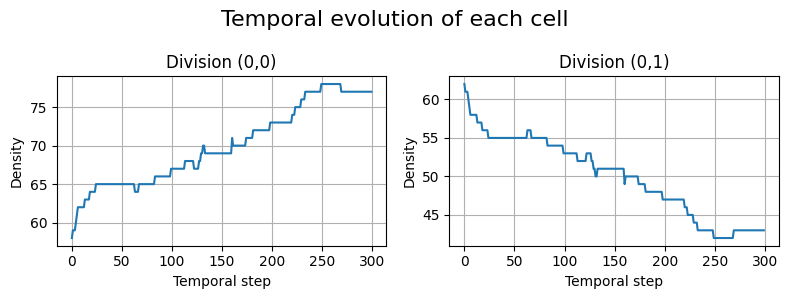

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ===== LEER EL FICHERO =====
with open("densidad.txt", "r", encoding="utf-8") as f:
    texto = f.read().strip()


# ===== SEPARAR LOS PASOS TEMPORALES =====
# Cada bloque separado por una línea en blanco es una matriz en un instante de tiempo
bloques = texto.split("\n\n")


matrices = []

for bloque in bloques:
    lineas = bloque.strip().split("\n")
    matriz = []

    for linea in lineas:
        fila = list(map(float, linea.split()))
        matriz.append(fila)

    matrices.append(matriz)

# Convertimos a array de numpy
datos = np.array(matrices)

# dimensiones: (tiempo, filas, columnas)
num_tiempos = datos.shape[0]
num_filas = datos.shape[1]
num_columnas = datos.shape[2]

# Vector temporal
t = np.arange(num_tiempos)

# ===== HACER LA FIGURA =====
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(4*num_columnas, 3*num_filas), sharex=True)

# Por si alguna vez la matriz fuese de 1 fila o 1 columna
if num_filas == 1 and num_columnas == 1:
    axes = np.array([[axes]])
elif num_filas == 1:
    axes = axes[np.newaxis, :]
elif num_columnas == 1:
    axes = axes[:, np.newaxis]

# ===== PLOT DE CADA CELDA =====
for i in range(num_filas):
    for j in range(num_columnas):
        axes[i, j].plot(t, datos[:, i, j])
        axes[i, j].set_title(f"Division ({i},{j})")
        axes[i, j].set_xlabel("Temporal step")
        axes[i, j].set_ylabel("Density")
        axes[i, j].grid(True)

fig.suptitle("Temporal evolution of each cell", fontsize=16)
fig.tight_layout()

# Guardar imagen
plt.savefig("plots/evolucion_densidad_celdas.png", dpi=200, bbox_inches="tight")

# Mostrar
plt.show()

### Presión sin promediar

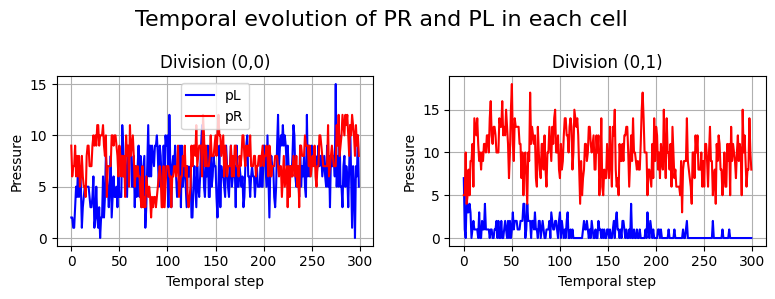

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# ===== FUNCIÓN PARA LEER UN FICHERO DE MATRICES =====
def leer_fichero_presion(nombre_fichero):
    with open(nombre_fichero, "r", encoding="utf-8") as f:
        texto = f.read().strip()

    # Cada bloque separado por una línea en blanco es una matriz
    bloques = texto.split("\n\n")

    matrices = []

    for bloque in bloques:
        lineas = bloque.strip().split("\n")
        matriz = []

        for linea in lineas:
            fila = list(map(float, linea.split()))
            matriz.append(fila)

        matrices.append(matriz)

    datos = np.array(matrices)

    return datos


# ===== LEER LOS DOS FICHEROS =====
datos_L = leer_fichero_presion("presionL.txt")
datos_R = leer_fichero_presion("presionR.txt")


# ===== COMPROBAR QUE TIENEN LA MISMA FORMA =====
if datos_L.shape != datos_R.shape:
    print("ERROR: presionL.txt y presionR.txt no tienen las mismas dimensiones")
    print("Forma de datos_L:", datos_L.shape)
    print("Forma de datos_R:", datos_R.shape)
else:

    # dimensiones: (tiempo, filas, columnas)
    num_tiempos = datos_L.shape[0]
    num_filas = datos_L.shape[1]
    num_columnas = datos_L.shape[2]

    # Vector temporal
    t = np.arange(num_tiempos)

    # ===== HACER LA FIGURA =====
    fig, axes = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(4*num_columnas, 3*num_filas),
        sharex=True
    )

    # Por si alguna vez la matriz fuese de 1 fila o 1 columna
    if num_filas == 1 and num_columnas == 1:
        axes = np.array([[axes]])
    elif num_filas == 1:
        axes = axes[np.newaxis, :]
    elif num_columnas == 1:
        axes = axes[:, np.newaxis]

    # ===== PLOT DE CADA CELDA =====
    for i in range(num_filas):
        for j in range(num_columnas):

            axes[i, j].plot(t, datos_L[:, i, j], color="blue", label="pL")
            axes[i, j].plot(t, datos_R[:, i, j], color="red", label="pR")

            axes[i, j].set_title(f"Division ({i},{j})")
            axes[i, j].set_xlabel("Temporal step")
            axes[i, j].set_ylabel("Pressure")
            axes[i, j].grid(True)

            # Para no saturar mucho, puedes poner leyenda solo en una celda
            if i == 0 and j == 0:
                axes[i, j].legend()

    fig.suptitle("Temporal evolution of PR and PL in each cell", fontsize=16)
    fig.tight_layout()

    # Guardar imagen
    plt.savefig("plots/evolucion_presion_L_R_celdas.png", dpi=300, bbox_inches="tight")

    # Mostrar
    plt.show()

### Densidad promediada

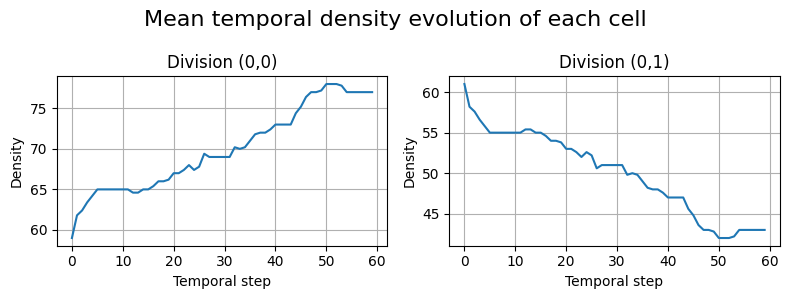

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ===== LEER EL FICHERO =====
with open("densidad_media.txt", "r", encoding="utf-8") as f:
    texto = f.read().strip()


# ===== SEPARAR LOS PASOS TEMPORALES =====
# Cada bloque separado por una línea en blanco es una matriz en un instante de tiempo
bloques = texto.split("\n\n")


matrices = []

for bloque in bloques:
    lineas = bloque.strip().split("\n")
    matriz = []

    for linea in lineas:
        fila = list(map(float, linea.split()))
        matriz.append(fila)

    matrices.append(matriz)

# Convertimos a array de numpy
datos = np.array(matrices)

# dimensiones: (tiempo, filas, columnas)
num_tiempos = datos.shape[0]
num_filas = datos.shape[1]
num_columnas = datos.shape[2]

# Vector temporal
t = np.arange(num_tiempos)

# ===== HACER LA FIGURA =====
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(4*num_columnas, 3*num_filas), sharex=True)

# Por si alguna vez la matriz fuese de 1 fila o 1 columna
if num_filas == 1 and num_columnas == 1:
    axes = np.array([[axes]])
elif num_filas == 1:
    axes = axes[np.newaxis, :]
elif num_columnas == 1:
    axes = axes[:, np.newaxis]

# ===== PLOT DE CADA CELDA =====
for i in range(num_filas):
    for j in range(num_columnas):
        axes[i, j].plot(t, datos[:, i, j])
        axes[i, j].set_title(f"Division ({i},{j})")
        axes[i, j].set_xlabel("Temporal step")
        axes[i, j].set_ylabel("Density")
        axes[i, j].grid(True)

fig.suptitle("Mean temporal density evolution of each cell", fontsize=16)
fig.tight_layout()

# Guardar imagen
plt.savefig("plots/evolucion_densidad_celdas_PROMEDIO.png", dpi=300, bbox_inches="tight")

# Mostrar
plt.show()

### Presión promediada

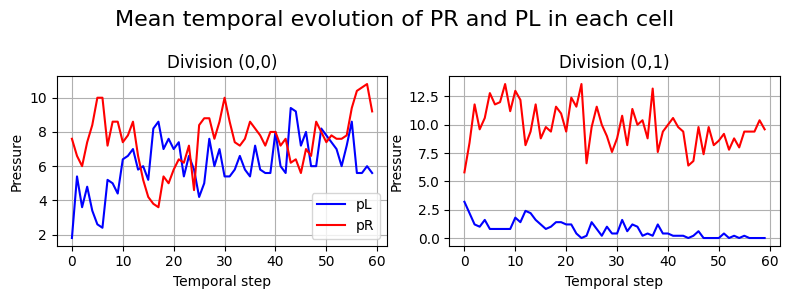

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# ===== FUNCIÓN PARA LEER UN FICHERO DE MATRICES =====
def leer_fichero_presion(nombre_fichero):
    with open(nombre_fichero, "r", encoding="utf-8") as f:
        texto = f.read().strip()

    # Cada bloque separado por una línea en blanco es una matriz
    bloques = texto.split("\n\n")

    matrices = []

    for bloque in bloques:
        lineas = bloque.strip().split("\n")
        matriz = []

        for linea in lineas:
            fila = list(map(float, linea.split()))
            matriz.append(fila)

        matrices.append(matriz)

    datos = np.array(matrices)

    return datos


# ===== LEER LOS DOS FICHEROS =====
datos_L = leer_fichero_presion("presionL_media.txt")
datos_R = leer_fichero_presion("presionR_media.txt")


# ===== COMPROBAR QUE TIENEN LA MISMA FORMA =====
if datos_L.shape != datos_R.shape:
    print("ERROR: presionL2.txt y presionR2.txt no tienen las mismas dimensiones")
    print("Forma de datos_L:", datos_L.shape)
    print("Forma de datos_R:", datos_R.shape)
else:

    # dimensiones: (tiempo, filas, columnas)
    num_tiempos = datos_L.shape[0]
    num_filas = datos_L.shape[1]
    num_columnas = datos_L.shape[2]

    # Vector temporal
    t = np.arange(num_tiempos)

    # ===== HACER LA FIGURA =====
    fig, axes = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(4*num_columnas, 3*num_filas),
        sharex=True
    )

    # Por si alguna vez la matriz fuese de 1 fila o 1 columna
    if num_filas == 1 and num_columnas == 1:
        axes = np.array([[axes]])
    elif num_filas == 1:
        axes = axes[np.newaxis, :]
    elif num_columnas == 1:
        axes = axes[:, np.newaxis]

    # ===== PLOT DE CADA CELDA =====
    for i in range(num_filas):
        for j in range(num_columnas):

            axes[i, j].plot(t, datos_L[:, i, j], color="blue", label="pL")
            axes[i, j].plot(t, datos_R[:, i, j], color="red", label="pR")

            axes[i, j].set_title(f"Division ({i},{j})")
            axes[i, j].set_xlabel("Temporal step")
            axes[i, j].set_ylabel("Pressure")
            axes[i, j].grid(True)

            # Para no saturar mucho, puedes poner leyenda solo en una celda
            if i == 0 and j == 0:
                axes[i, j].legend()

    fig.suptitle("Mean temporal evolution of PR and PL in each cell", fontsize=16)
    fig.tight_layout()

    # Guardar imagen
    plt.savefig("plots/evolucion_presion_L_R_celdas_PROMEDIO.png", dpi=300, bbox_inches="tight")

    # Mostrar
    plt.show()

### Presión en el muro central sin promediar

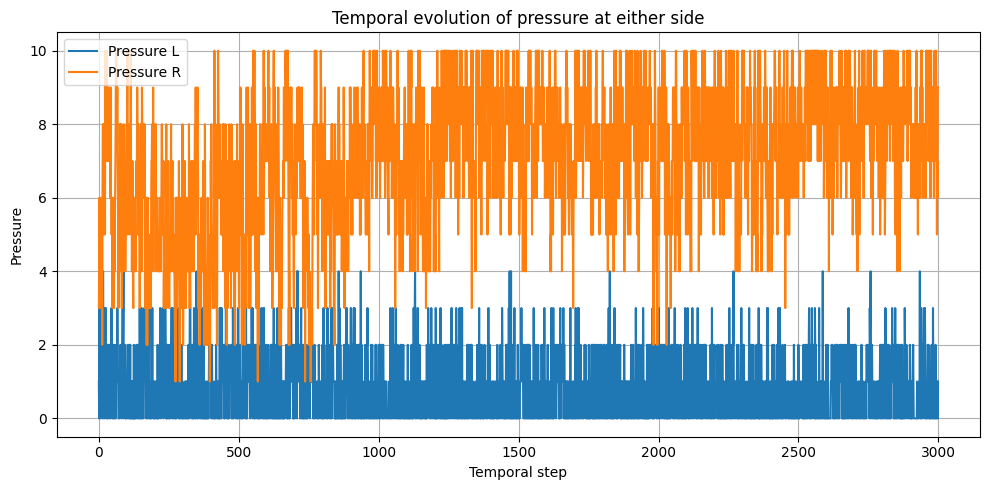

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARÁMETROS
# =========================================================
nombre_archivo = "presion_mitad.txt"

# =========================================================
# LEER DATOS
# =========================================================
# Cada fila es un paso temporal
# Cada columna es una curva distinta
datos = np.loadtxt(nombre_archivo)

# Columna 0 -> primera presión
# Columna 1 -> segunda presión
presion_1 = datos[:, 0]
presion_2 = datos[:, 1]

# Eje x: pasos temporales
pasos = np.arange(len(presion_1))

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(10, 5))

plt.plot(pasos, presion_1, label="Pressure L")
plt.plot(pasos, presion_2, label="Pressure R")

plt.xlabel("Temporal step")
plt.ylabel("Pressure")
plt.title("Temporal evolution of pressure at either side")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/presiones_mitad.png", dpi=300)

plt.show()

### Presión en el muro PROMEDIADA

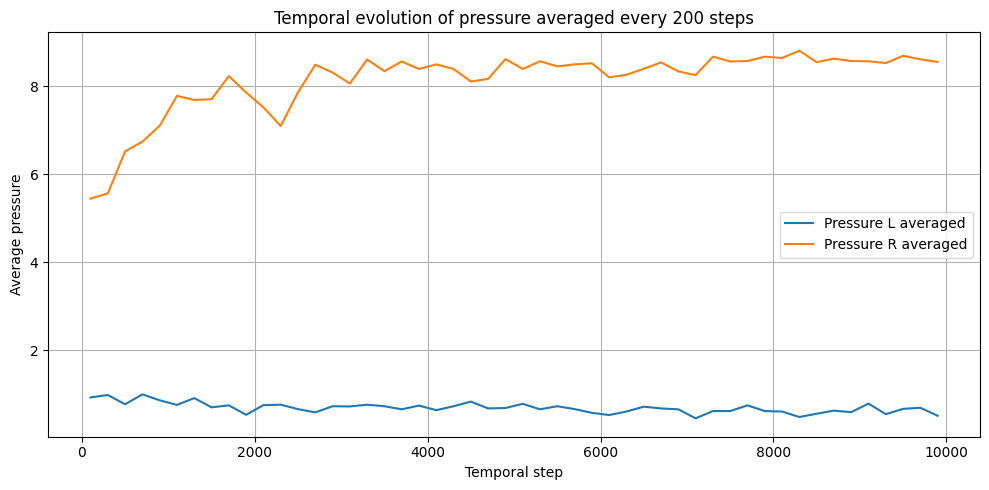

In [15]:
X = 200   # Número de pasos temporales que quieres promediar

import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================================
# PARÁMETROS
# =========================================================
nombre_archivo = "presion_mitad.txt"



guardar_plot = True
nombre_plot = f"plots/presiones_mitad_promedio_X={X}.png"

# =========================================================
# LEER DATOS
# =========================================================
# Cada fila es un paso temporal
# Cada columna es una curva distinta
datos = np.loadtxt(nombre_archivo)

presion_1 = datos[:, 0]
presion_2 = datos[:, 1]

# =========================================================
# PROMEDIAR CADA X PASOS TEMPORALES
# =========================================================
num_pasos = len(presion_1)

presion_1_prom = []
presion_2_prom = []
pasos_prom = []

for i in range(0, num_pasos, X):
    bloque_1 = presion_1[i:i+X]
    bloque_2 = presion_2[i:i+X]

    # Si el último bloque tiene menos de X datos, también lo promedia
    media_1 = np.mean(bloque_1)
    media_2 = np.mean(bloque_2)

    presion_1_prom.append(media_1)
    presion_2_prom.append(media_2)

    # Usamos como paso temporal el centro del bloque
    pasos_prom.append(i + len(bloque_1)/2)

presion_1_prom = np.array(presion_1_prom)
presion_2_prom = np.array(presion_2_prom)
pasos_prom = np.array(pasos_prom)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(10, 5))

plt.plot(pasos_prom, presion_1_prom, label="Pressure L averaged")
plt.plot(pasos_prom, presion_2_prom, label="Pressure R averaged")

plt.xlabel("Temporal step")
plt.ylabel("Average pressure")
plt.title(f"Temporal evolution of pressure averaged every {X} steps")

plt.legend()
plt.grid(True)
plt.tight_layout()

# =========================================================
# GUARDAR
# =========================================================
if guardar_plot:
    os.makedirs("plots", exist_ok=True)
    plt.savefig(nombre_plot, dpi=300)

plt.show()